# Swansea Flood Risk Vs Deprivation Analysis
Do more deprived areas in Swansea face more flood risk?

In [51]:
# Imports
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## Load, Preview and Merge Data

In [52]:
# Load and preview LSOA data
lsoa = gpd.read_file('../data/LSOA_2011_EW_BFC_V3.shp')
print(lsoa.columns.tolist())
print(lsoa.head())

['LSOA11CD', 'LSOA11NM', 'BNG_E', 'BNG_N', 'LONG_', 'LAT', 'Shape_Leng', 'GlobalID', 'geometry']
    LSOA11CD                   LSOA11NM   BNG_E   BNG_N     LONG_      LAT  \
0  E01000001        City of London 001A  532123  181632 -0.097140  51.5182   
1  E01000002        City of London 001B  532480  181715 -0.091970  51.5188   
2  E01000003        City of London 001C  532239  182033 -0.095320  51.5217   
3  E01000005        City of London 001E  533581  181283 -0.076270  51.5147   
4  E01000006  Barking and Dagenham 016A  544994  184274  0.089317  51.5387   

    Shape_Leng                              GlobalID  \
0  2635.767993  eaf9e4b8-fcc1-4cae-a46c-22c8a43ff39b   
1  2707.881853  4434ca6e-e270-4e88-b3eb-4cfb37f62490   
2  1224.638192  d0ff9760-86dc-40da-ad33-3b1dc987ef04   
3  2275.805348  474caa9f-a6e3-4de2-8bc1-2f5b0da40271   
4  1966.092607  ff2bc9a6-9e26-4415-9cec-eaea2c0a4f54   

                                            geometry  
0  POLYGON ((532151.537 181867.433, 532152

Swansea LSOAs: 148


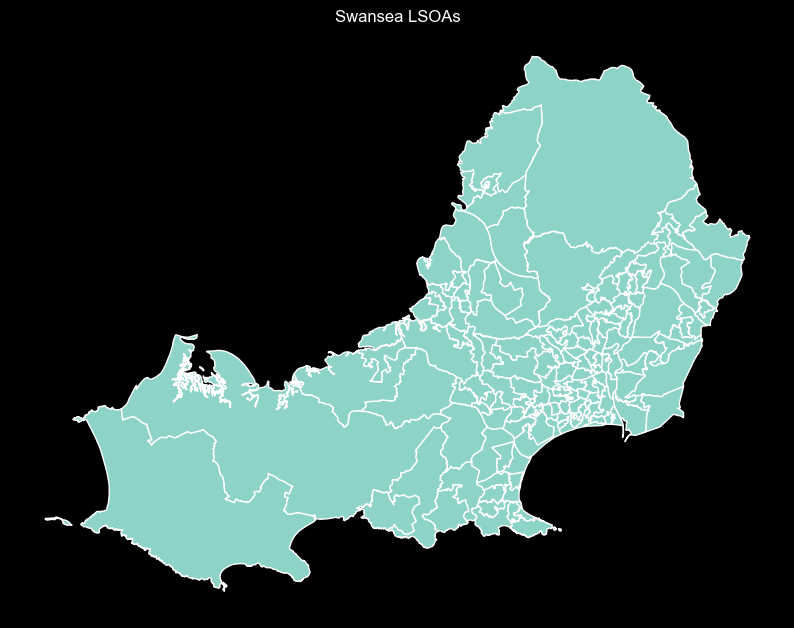

In [53]:
# Clip data to just Swansea and save file
swansea_lsoa = lsoa[lsoa['LSOA11NM'].str.startswith('Swansea')].copy()
print(f'Swansea LSOAs: {len(swansea_lsoa)}')
swansea_lsoa.to_file("../data/swansea_lsoa.geojson", driver="GeoJSON")

# Plot LSOA's
ax = swansea_lsoa.plot(figsize=(10,8))
ax.set_title('Swansea LSOAs')
ax.set_axis_off()

In [54]:
# Load WIMD data preview and remove blank spaces in column names
wimd = pd.read_excel('../data/WIMD2019Swansea.xlsx')
print(wimd.columns.tolist())
wimd.columns = wimd.columns.str.strip()
print(wimd.columns.tolist())
print(wimd.shape)

['LSOA Code', 'LSOA Name', 'WIMD 2019 ', 'Income ', 'Employment', 'Health', 'Education ', 'Access to Services', 'Housing', 'Community Safety', 'Physical Environment']
['LSOA Code', 'LSOA Name', 'WIMD 2019', 'Income', 'Employment', 'Health', 'Education', 'Access to Services', 'Housing', 'Community Safety', 'Physical Environment']
(148, 11)


In [55]:
# Merge boundary data with deprivation data
merged = swansea_lsoa.merge(wimd, left_on='LSOA11CD', right_on='LSOA Code', how='left')
print(merged.shape)

# Check for failed matches
print(merged['WIMD 2019'].isna().sum(), 'unmatched')

(148, 20)
0 unmatched


In [56]:
# Check coordinate system of spatial data
print(merged.crs)

EPSG:27700


In [ ]:
# Load and preview flood risk data for Swansea
flood = gpd.read_file('../data/rivers_sea.json')
print(flood.crs)
print(flood.shape)
print(flood.columns.tolist())
print(flood.head())

In [ ]:
swansea_bounds = merged.total_bounds
print(swansea_bounds)

In [ ]:
flood_swansea = flood.cx[swansea_bounds[0]:swansea_bounds[2], swansea_bounds[1]:swansea_bounds[3]]
print('Clipped:', flood_swansea.shape)
flood_swansea.to_file('../data/flood_swansea.gpkg', driver='GPKG')

In [ ]:
# Check naming of risk scores
print(flood_swansea.risk.value_counts())

In [ ]:
# Extract Flood Zone 2 & 3
fz3 = flood_swansea[flood_swansea['risk'] == 'Flood Zone 3'].copy()
fz2 = flood_swansea[flood_swansea['risk'] == 'Flood Zone 2'].copy()

In [ ]:
# Merge polygon fragments into single geometry
fz3_dissolved = fz3.dissolve()
fz2_dissolved = fz2.dissolve()

In [ ]:
# Calculate LSOA & Flood Zone overlap for flood exposure
merged['lsoa_area'] = merged.geometry.area

merged['fz3_area'] = merged.geometry.intersection(fz3_dissolved.geometry.union_all()).area
merged['fz2_area'] = merged.geometry.intersection(fz2_dissolved.geometry.union_all()).area

merged['pct_fz3'] = (merged['fz3_area'] / merged['lsoa_area']) * 100
merged['pct_fz2'] = (merged['fz2_area'] / merged['lsoa_area']) * 100

In [ ]:
# Preview merged dataset
print(merged[['LSOA11NM', 'WIMD 2019', 'pct_fz3', 'pct_fz2']].sort_values('pct_fz3', ascending=False).head(10))

## Visualisations

In [ ]:
# Scatter plot: deprivation rank vs flood exposure
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    merged['WIMD 2019'],
    merged['pct_fz3'],
    c=merged['WIMD 2019'],
    cmap='RdYlGn',
    alpha=0.7,
    edgecolor='black',
    linewidths=0.5,
)
plt.colorbar(scatter, ax=ax, label='WIMD 2019 Rank (1=Most Deprived)')
ax.set_xlabel('WIMD 2019 Rank (1=Most Deprived)')
ax.set_ylabel('% of LSOA in Flood Zone 3')
ax.set_title('Swansea: Deprivation vs Flood Zone 3 Exposure')
plt.tight_layout()
plt.savefig('../outputs/scatter_deprivation_flood.png', dpi=150)
plt.show()

In [ ]:
# Choropleth map of flood exposure
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

merged.plot(column='pct_fz3', ax=axes[0], cmap='Blues',
            legend=True, legend_kwds={'label': '% in Flood Zone 3'})
axes[0].set_title('Flood Zone 3 Exposure by LSOA')
axes[0].axis('off')

merged.plot(column='WIMD 2019', ax=axes[1], cmap='Reds_r',
            legend=True, legend_kwds={'label': 'WIMD Rank (1=most deprived)'})
axes[1].set_title('Deprivation (WIMD 2019) by LSOA')
axes[1].axis('off')

plt.suptitle('Swansea: Flood Risk vs Deprivation', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/maps_flood_deprivation.png', dpi=150)
plt.show()

In [ ]:
# Group LSOAs into 5 equal deprivation bands (quintiles)
# Q1 = most deprived 20% of LSOAs, Q5 = least deprived 20%
merged['wimd_quintile'] = pd.qcut(
    merged['WIMD 2019'],
    q=5,
    labels=['Q1\n(Most Deprived)', 'Q2', 'Q3', 'Q4', 'Q5\n(Least Deprived)']
)

# Calculate mean FZ3 & FZ2 exposure for each deprivation quintile
quintile_means_fz3 = merged.groupby('wimd_quintile', observed=True)['pct_fz3'].mean()
quintile_means_fz2 = merged.groupby('wimd_quintile', observed=True)['pct_fz2'].mean()

# Shared colours — red to green representing most to least deprived
colours = ['#c0392b', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Chart FZ3
bars3 = axes[0].bar(
    quintile_means_fz3.index,
    quintile_means_fz3.values,
    color=colours,
    edgecolor='white',
    width=0.6
)
axes[0].bar_label(bars3, fmt='%.1f%%', padding=3, fontsize=10)
axes[0].set_xlabel('WIMD 2019 Deprivation Quintile', fontsize=11)
axes[0].set_ylabel('Mean % of LSOA Area', fontsize=11)
axes[0].set_title('Flood Zone 3 Exposure\nby Deprivation Quintile', fontsize=12, fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(False)

# Right Chart FZ2
bars2 = axes[1].bar(
    quintile_means_fz2.index,
    quintile_means_fz2.values,
    color=colours,
    edgecolor='white',
    width=0.6
)
axes[1].bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=10)
axes[1].set_xlabel('WIMD 2019 Deprivation Quintile', fontsize=11)
axes[1].set_ylabel('Mean % of LSOA Area', fontsize=11)
axes[1].set_title('Flood Zone 2 Exposure\nby Deprivation Quintile', fontsize=12, fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(False)

plt.suptitle('Swansea: Average Flood Exposure by Deprivation Quintile',
             fontsize=14, fontweight='bold', y=1.02)

# Set both y-axes to the same scale for fair comparison
y_max = max(quintile_means_fz3.max(), quintile_means_fz2.max()) * 1.2
axes[0].set_ylim(0, y_max)
axes[1].set_ylim(0, y_max)

plt.tight_layout()
plt.savefig('../outputs/fz2_fz3_by_quintile.png', dpi=150, bbox_inches='tight')
plt.show()